<a href="https://colab.research.google.com/github/jasper1011-tech/task1ml_MainCrafts/blob/main/task1_ml_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


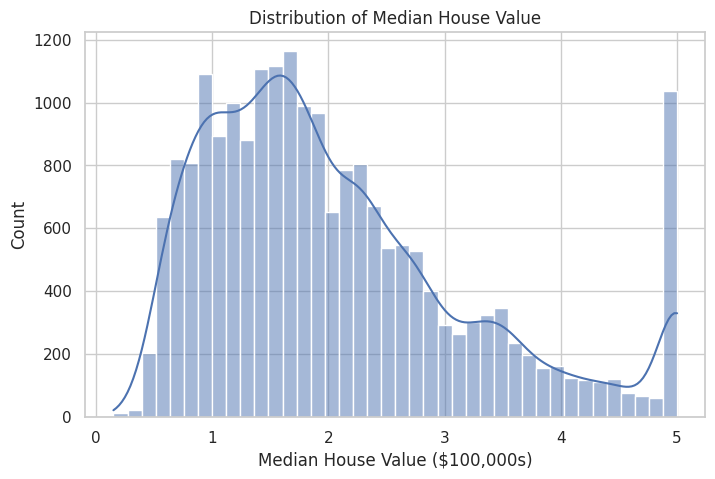

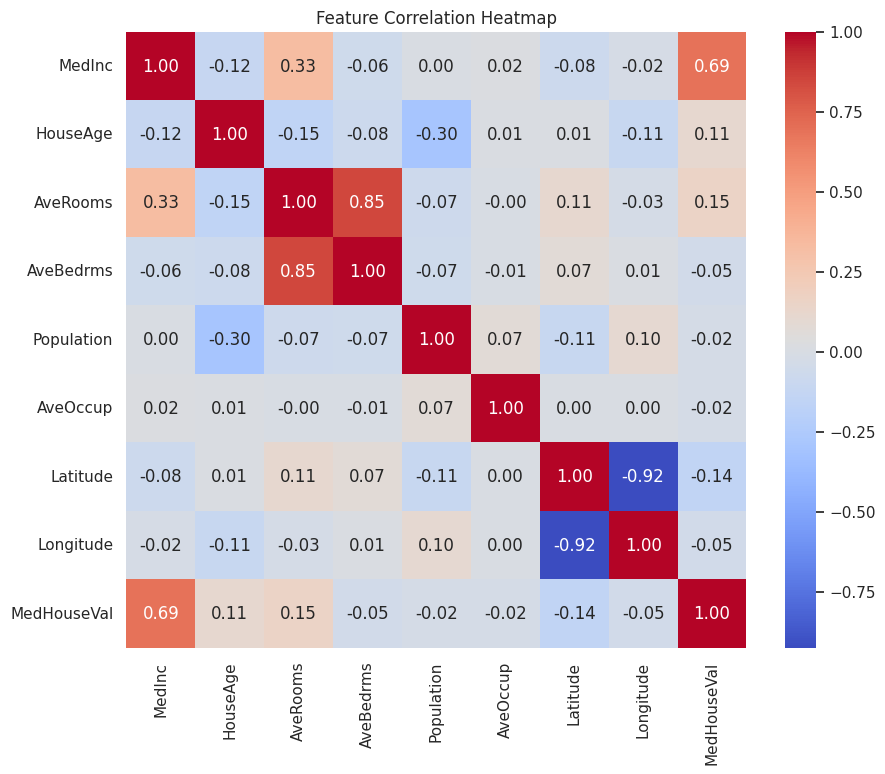

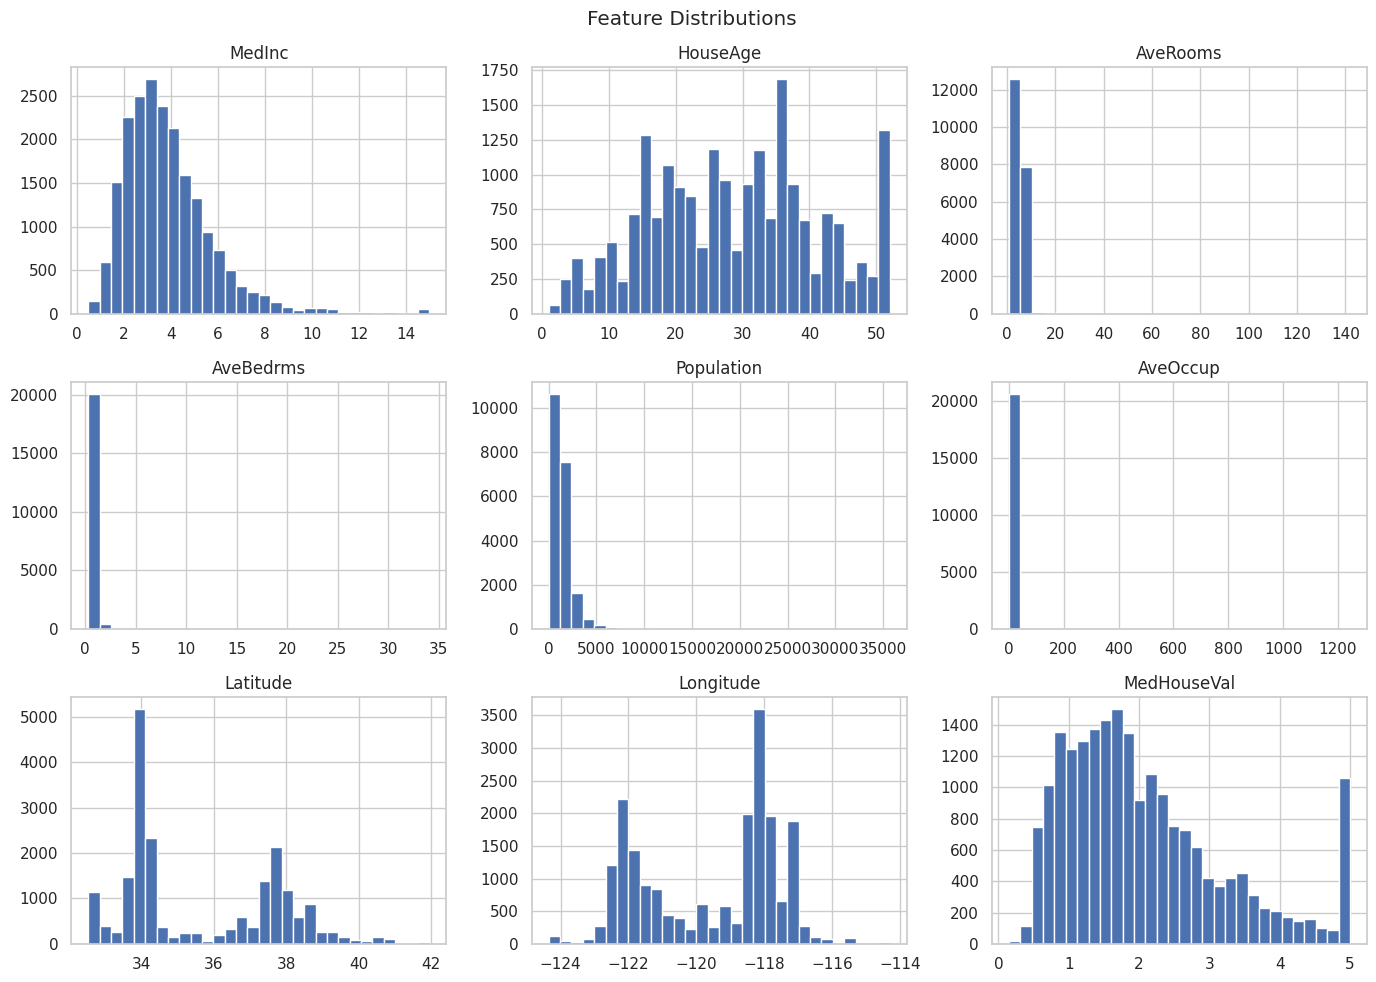

Training set size: (16512, 8)
Testing set size: (4128, 8)
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708
MAE  (Mean Absolute Error): 0.533
RMSE (Root Mean Squared Error): 0.746
R2   (R-squared): 0.576


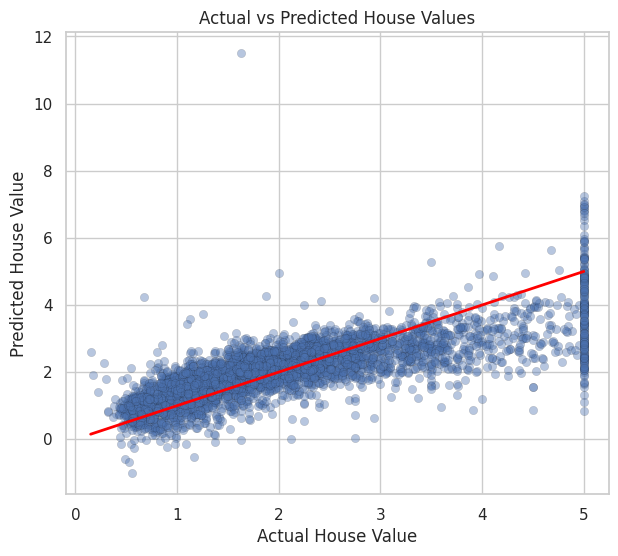

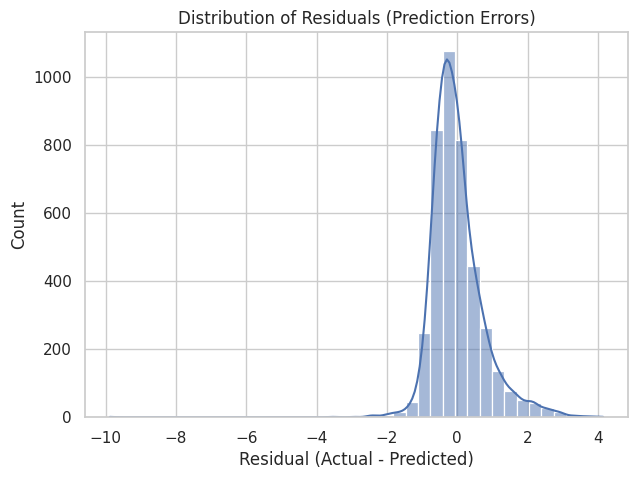

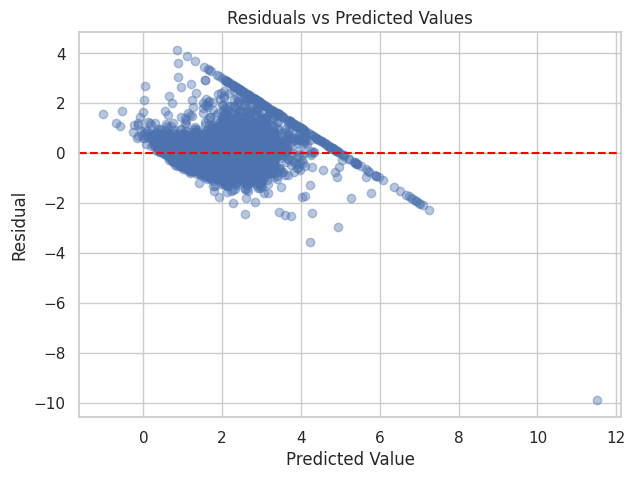

Model saved as house_price_model.pkl


In [1]:
# ==== 1. Import Libraries ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")


# ==== 2. Load Dataset ====
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)
print("Shape:", df.shape)
df.head()


# ==== 3. EDA ====
df.info()
df.describe()

print("Missing values per column:")
print(df.isnull().sum())

# Distribution of target
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=40, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($100,000s)')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Feature histograms
df.hist(bins=30, figsize=(14, 10))
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()


# ==== 4. Feature Selection & Train/Test Split ====
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


# ==== 5. Train Model ====
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)
print(coef_df)


# ==== 6. Evaluate ====
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): {mae:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"R2   (R-squared): {r2:.3f}")


# ==== 7. Visualize Predictions ====
# Predicted vs Actual
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.4, edgecolor='k', linewidth=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Values')
plt.show()

# Residuals distribution
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title('Distribution of Residuals (Prediction Errors)')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Values')
plt.show()


# ==== 8. (Optional) Save the Model ====
import pickle
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved as house_price_model.pkl")